# SNOLAB R4 Template Generation
**Data**: `Prompt_V07-02_C0.4.5` — 9 series in Submerged  
**Kernel**: `scdms-V07-02-shared`  

## Outline
1. Energy Spectrum (PTOFamps, all series, all detectors)
2. 1×1 Template Generation (noise filter → align → average → exponential fit → write ROOT)
3. N×M Template Generation (PCA on aligned traces → write ROOT)

In [1]:
import rawio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cdms
import ROOT
from ROOT import TFile, TH1D
from cats.cdataframe import CDataFrame
from scipy.optimize import curve_fit
from scipy.signal import butter, sosfilt
from scipy import signal
from sklearn.decomposition import PCA
import uproot
import glob, os, warnings

print("CDMS Software Version:", cdms.get_global_version())

CDMS Software Version: V07-02-00


In [2]:
# ── Paths and global config ────────────────────────────────────────────────────
PROCESSED_DIR = "/projects/standard/yanliusp/shared/data/CDMS/SNOLAB/R4/Processed/Prompt/Prompt_V07-02_C0.4.5/Submerged"
RAW_DIR       = "/projects/standard/yanliusp/shared/data/CDMS/SNOLAB/R4/Raw"
PROD_TAG      = "Prompt_V07-02_C0.4.5"
samplerate    = 625000
tracelength   = 32768

# Build series list from filenames
all_proc_files = sorted(glob.glob(f"{PROCESSED_DIR}/{PROD_TAG}_*.root"))
series_list    = [os.path.basename(f).replace(f"{PROD_TAG}_", "").replace(".root", "") for f in all_proc_files]
print(f"Found {len(series_list)} series:")
for s in series_list:
    print(f"  {s}")

# Per-detector PTOFamps amplitude ranges [A] — selected from the PTOFamps vs PTOFchisq plot
# Only detectors listed here are included in template generation
PTOF_RANGES = {
     1: (7.5e-7, 1.05e-6),
     4: (1.1e-6,  1.6e-6),
     6: (1.1e-6,  2.0e-6),
     7: (7.0e-7,  1.2e-6),
    10: (1.1e-6,  1.7e-6),
    15: (2.0e-6,  3.0e-6),
    16: (2.4e-6,  3.5e-6),
    18: (2.3e-6,  3.6e-6),
}

# All detectors present in the processed files (for spectrum plots)
dets_all = [1, 4, 6, 7, 9, 10, 15, 16, 18, 24]

# Primary detector for template generation (change to any key in PTOF_RANGES)
det_tmpl = 1

# All possible phonon channels
ALL_CHANS = ['PAS1','PBS1','PCS1','PDS1','PES1','PFS1',
             'PAS2','PBS2','PCS2','PDS2','PES2','PFS2']

# Auto-detect which channels are actually present for each detector
_ref_file = all_proc_files[0]
det_chan_map = {}
with uproot.open(_ref_file) as _f:
    for _det in dets_all:
        try:
            _keys = list(_f[f'rqDir/zip{_det}'].keys())
            det_chan_map[_det] = [c for c in ALL_CHANS if f'{c}OFdelay' in _keys]
        except Exception:
            det_chan_map[_det] = []

# Channels for the primary template detector
chan_names = det_chan_map[det_tmpl]
print(f"\nZip{det_tmpl} channels ({len(chan_names)}): {chan_names}")
for d in dets_all:
    missing = [c for c in ALL_CHANS if c not in det_chan_map[d]]
    tag = f"  missing: {missing}" if missing else ""
    print(f"  zip{d:2d}: {len(det_chan_map[d])} channels{tag}")

Found 9 series:
  24260615_235328
  24260616_011402
  24260616_021845
  24260616_032333
  24260616_033235
  24260616_045309
  24260616_055753
  24260616_063504
  24260616_074337

Zip1 channels (9): ['PAS1', 'PBS1', 'PCS1', 'PES1', 'PFS1', 'PAS2', 'PCS2', 'PDS2', 'PES2']
  zip 1: 9 channels  missing: ['PDS1', 'PBS2', 'PFS2']
  zip 4: 11 channels  missing: ['PBS1']
  zip 6: 12 channels
  zip 7: 11 channels  missing: ['PFS2']
  zip 9: 11 channels  missing: ['PFS2']
  zip10: 11 channels  missing: ['PFS2']
  zip15: 11 channels  missing: ['PAS1']
  zip16: 9 channels  missing: ['PAS1', 'PAS2', 'PES2']
  zip18: 11 channels  missing: ['PCS2']
  zip24: 12 channels


---
## Part 1 — Energy Spectrum (PTOFamps)
Read `PTOFamps` from all series for every detector using `uproot`, then plot histograms.

In [3]:
# Collect PTOFamps for each detector across all series
# Filter: TriggerType==1 (physics trigger) and PTOFamps != -999999 (sentinel/bad value)
ptof_all = {det: [] for det in dets_all}

for fpath in all_proc_files:
    with uproot.open(fpath) as f:
        trig_type = f["rqDir/eventTree/TriggerType"].array(library="np")
        phys      = (trig_type == 1)
        for det in dets_all:
            try:
                amps  = f[f"rqDir/zip{det}/PTOFamps"].array(library="np")
                valid = phys & (amps != -999999)
                ptof_all[det].extend(amps[valid].tolist())
            except Exception:
                pass

for det in dets_all:
    ptof_all[det] = np.array(ptof_all[det])
    print(f"Zip{det:2d}: {len(ptof_all[det])} physics events")

Zip 1: 5596 physics events
Zip 4: 6641 physics events
Zip 6: 6086 physics events
Zip 7: 23789 physics events
Zip 9: 5532 physics events
Zip10: 5504 physics events
Zip15: 5183 physics events
Zip16: 4424 physics events
Zip18: 5473 physics events
Zip24: 5690 physics events


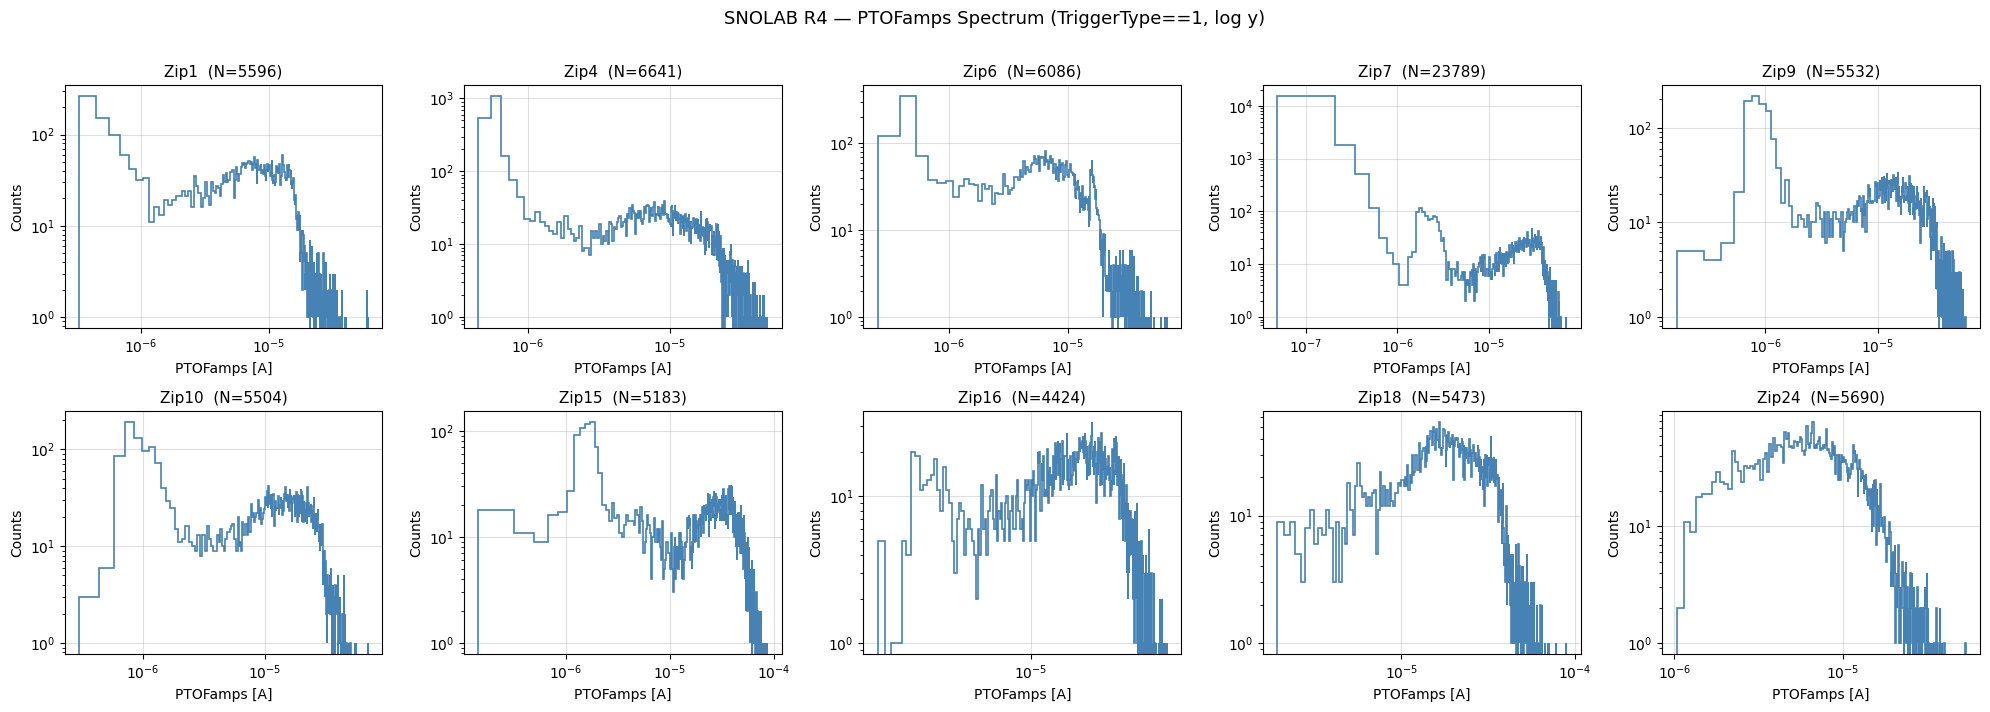

In [4]:
# Plot PTOFamps spectrum for each detector
# x-axis: symlog (handles negatives + wide positive dynamic range)
# y-axis: log scale
n_dets    = len(dets_all)
ncols     = 5
nrows     = (n_dets + ncols - 1) // ncols
linthresh = 1e-7

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()
for idx, det in enumerate(dets_all):
    ax   = axes[idx]
    amps = ptof_all[det]
    if len(amps) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"Zip{det}")
        continue
    bins = np.linspace(amps.min(), amps.max(), 500)
    ax.hist(amps, bins=bins, histtype='step', color='steelblue', linewidth=1.2)
    ax.set_xscale('symlog', linthresh=linthresh)
    ax.set_yscale('log')
    ax.set_xlabel('PTOFamps [A]', fontsize=10)
    ax.set_ylabel('Counts', fontsize=10)
    ax.set_title(f"Zip{det}  (N={len(amps)})", fontsize=11)
    ax.grid(alpha=0.4)
for idx in range(n_dets, len(axes)):
    axes[idx].set_visible(False)
fig.suptitle("SNOLAB R4 — PTOFamps Spectrum (TriggerType==1, log y)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

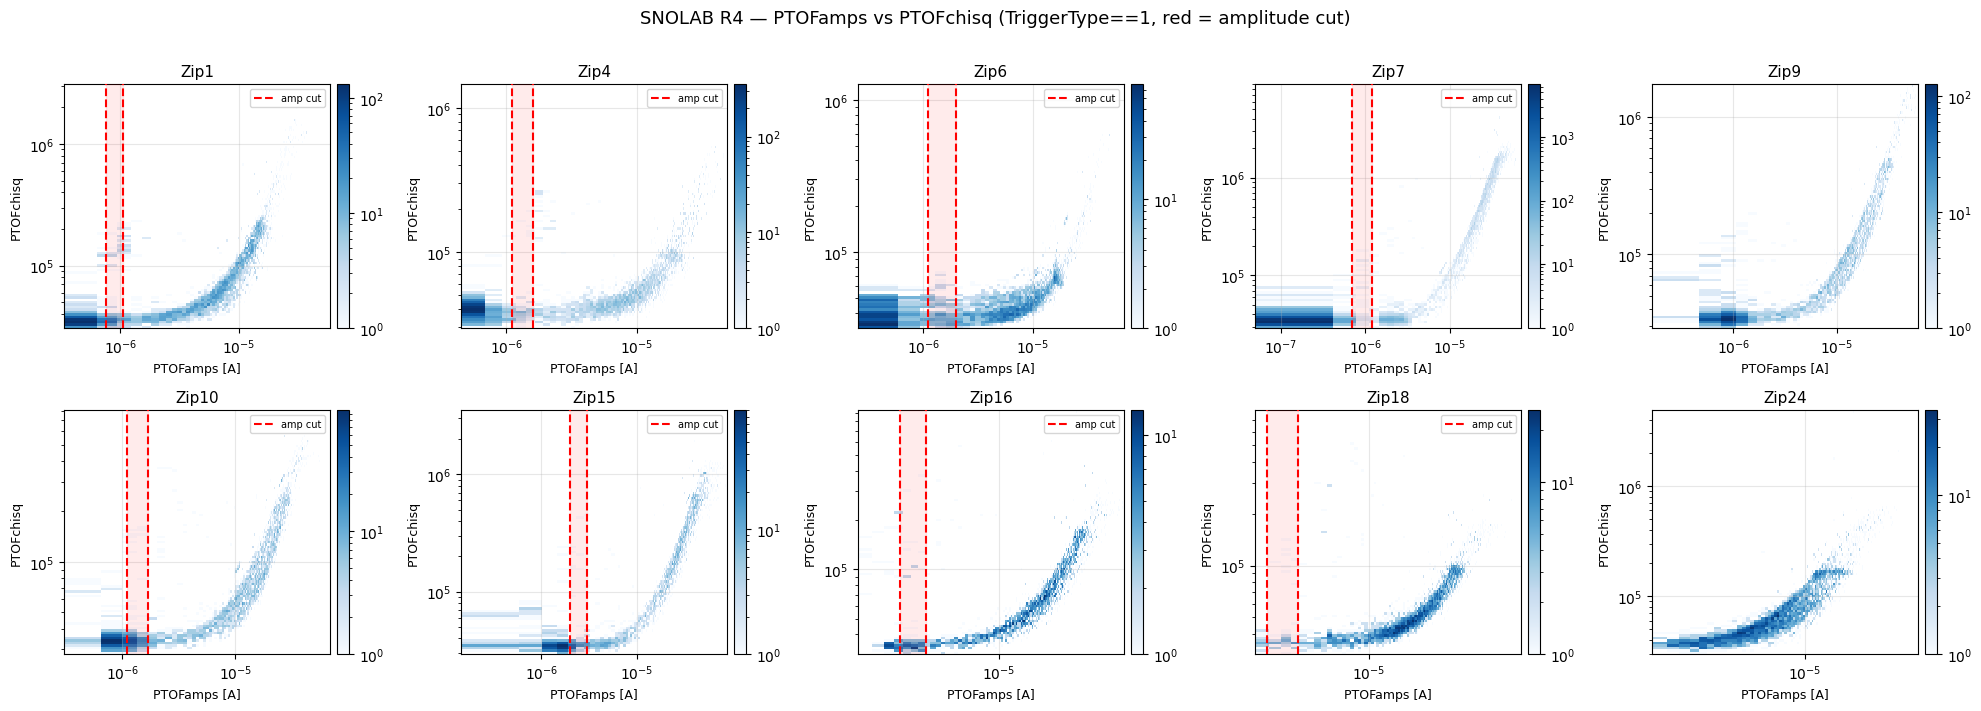

In [5]:
# PTOFamps vs PTOFchisq — 2D density plot for each detector
# Red dashed lines + shaded band show the selected PTOFamps cut range (PTOF_RANGES)
ptof_chisq_all = {det: [] for det in dets_all}
ptof_amps_sc   = {det: [] for det in dets_all}

for fpath in all_proc_files:
    with uproot.open(fpath) as f:
        trig_type = f["rqDir/eventTree/TriggerType"].array(library="np")
        phys      = (trig_type == 1)
        for det in dets_all:
            try:
                amps  = f[f"rqDir/zip{det}/PTOFamps"].array(library="np")
                chisq = f[f"rqDir/zip{det}/PTOFchisq"].array(library="np")
                valid = phys & (amps != -999999) & (chisq != -999999) & (chisq > 0)
                ptof_amps_sc[det].extend(amps[valid].tolist())
                ptof_chisq_all[det].extend(chisq[valid].tolist())
            except Exception:
                pass

for det in dets_all:
    ptof_amps_sc[det]   = np.array(ptof_amps_sc[det])
    ptof_chisq_all[det] = np.array(ptof_chisq_all[det])

# Plot
n_dets = len(dets_all)
ncols  = 5
nrows  = (n_dets + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for idx, det in enumerate(dets_all):
    ax    = axes[idx]
    amps  = ptof_amps_sc[det]
    chisq = ptof_chisq_all[det]

    if len(amps) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"Zip{det}")
        continue

    # 2D histogram
    chisq_bins = np.logspace(np.log10(chisq.min()), np.log10(chisq.max()), 100)
    amps_bins  = np.linspace(amps.min(), amps.max(), 200)
    h, xedges, yedges = np.histogram2d(amps, chisq, bins=[amps_bins, chisq_bins])
    h = np.ma.masked_where(h == 0, h)
    pcm = ax.pcolormesh(xedges, yedges, h.T,
                        norm=plt.matplotlib.colors.LogNorm(),
                        cmap='Blues', rasterized=True)
    fig.colorbar(pcm, ax=ax, pad=0.02)
    ax.set_xscale('symlog', linthresh=1e-7)
    ax.set_yscale('log')
    ax.set_xlabel('PTOFamps [A]', fontsize=9)
    ax.set_ylabel('PTOFchisq', fontsize=9)
    ax.set_title(f"Zip{det}", fontsize=11)
    ax.grid(alpha=0.3)

    # Overlay amplitude cut range if this detector is in PTOF_RANGES
    if det in PTOF_RANGES:
        lo, hi = PTOF_RANGES[det]
        ax.axvline(lo, color='red', lw=1.5, ls='--', zorder=5, label='amp cut')
        ax.axvline(hi, color='red', lw=1.5, ls='--', zorder=5)
        ax.axvspan(lo, hi, color='red', alpha=0.08, zorder=4)
        ax.legend(fontsize=7, loc='upper right')

for idx in range(n_dets, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("SNOLAB R4 — PTOFamps vs PTOFchisq (TriggerType==1, red = amplitude cut)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

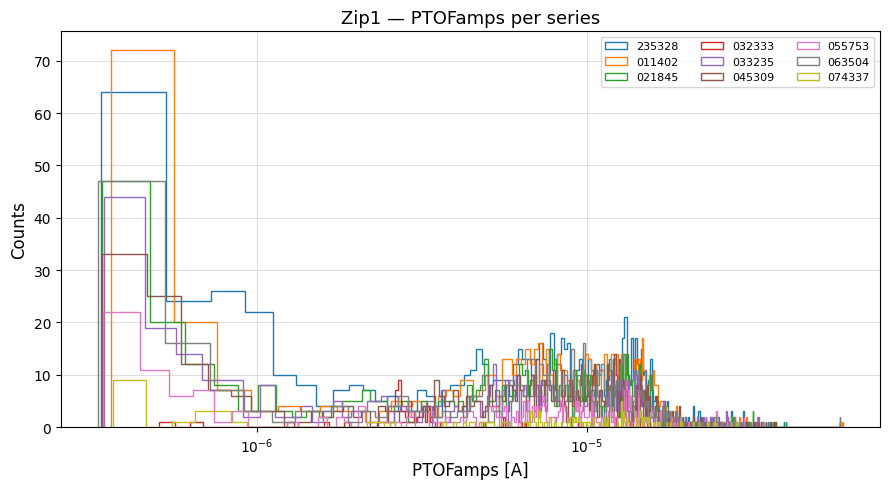

In [6]:
# Per-series overlay for the primary template detector (symlog x-axis)
fig, ax = plt.subplots(figsize=(9, 5))
for fpath, series in zip(all_proc_files, series_list):
    with uproot.open(fpath) as f:
        try:
            trig_type = f["rqDir/eventTree/TriggerType"].array(library="np")
            amps      = f[f"rqDir/zip{det_tmpl}/PTOFamps"].array(library="np")
            valid     = (trig_type == 1) & (amps != -999999)
            amps      = amps[valid]
            if len(amps) > 0:
                bins = np.linspace(amps.min(), amps.max(), 300)
                ax.hist(amps, bins=bins, histtype='step', linewidth=1, label=series[-6:])
        except Exception:
            pass
ax.set_xscale('symlog', linthresh=1e-7)
ax.set_xlabel('PTOFamps [A]', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title(f"Zip{det_tmpl} — PTOFamps per series", fontsize=13)
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

---
## Part 2 — 1×1 Template Generation

**Pipeline:**  
1. CDataFrame event selection (TriggerType==1, PTOFamps range)  
2. Read raw traces via `rawio`  
3. Baseline subtract → Butterworth low-pass filter → align with `OFdelay`  
4. Average normalised traces → template  
5. Fit (3-exp preferred, 2-exp fallback)  
6. Build PT / PS1 / PS2 composites  
7. Write to ROOT file  

### Step 1 — Event Selection with CDataFrame

In [7]:
# Event selection — all detectors in PTOF_RANGES
# sel_events_all[det][series]        → selected EventNumbers
# sel_delay_all[det][series][chan]    → {evnum: delay_s}
# sel_baseline_all[det][series][chan] → {evnum: baseline}

sel_events_all   = {}
sel_delay_all    = {}
sel_baseline_all = {}

for det in PTOF_RANGES:
    PTOF_LO, PTOF_HI = PTOF_RANGES[det]
    chans = det_chan_map[det]
    print(f"\nZip{det} — cut: {PTOF_LO:.2e} < PTOFamps < {PTOF_HI:.2e}")
    sel_events_all[det]   = {}
    sel_delay_all[det]    = {}
    sel_baseline_all[det] = {}

    for fpath, series in zip(all_proc_files, series_list):
        try:
            with uproot.open(fpath) as f:
                trig_type = f['rqDir/eventTree/TriggerType'].array(library='np')
                event_num = f['rqDir/eventTree/EventNumber'].array(library='np').astype(int)
                ptof_amps = f[f'rqDir/zip{det}/PTOFamps'].array(library='np')

                mask   = (trig_type == 1) & (ptof_amps != -999999) & \
                         (ptof_amps > PTOF_LO) & (ptof_amps < PTOF_HI)
                evnums = event_num[mask]

                sel_events_all[det][series]   = evnums
                sel_delay_all[det][series]    = {}
                sel_baseline_all[det][series] = {}
                for c in chans:
                    try:
                        delay_arr = f[f'rqDir/zip{det}/{c}OFdelay'].array(library='np')[mask]
                        bs_arr    = f[f'rqDir/zip{det}/{c}bs'].array(library='np')[mask]
                    except Exception:
                        delay_arr = np.zeros(len(evnums))
                        bs_arr    = np.zeros(len(evnums))
                    sel_delay_all[det][series][c]    = dict(zip(evnums, delay_arr))
                    sel_baseline_all[det][series][c] = dict(zip(evnums, bs_arr))

            print(f'  {series}: {len(evnums)} events selected')
        except Exception as e:
            print(f'  {series}: ERROR — {e}')
            sel_events_all[det][series]   = np.array([], dtype=int)
            sel_delay_all[det][series]    = {c: {} for c in chans}
            sel_baseline_all[det][series] = {c: {} for c in chans}

    total = sum(len(v) for v in sel_events_all[det].values())
    print(f'  → Zip{det} total: {total} events')
    if total < 100:
        print(f"  WARNING: only {total} events — consider widening PTOF_RANGES[{det}]")

# Aliases for the primary template detector (used by downstream cells)
sel_events   = sel_events_all[det_tmpl]
sel_delay    = sel_delay_all[det_tmpl]
sel_baseline = sel_baseline_all[det_tmpl]
chan_names   = det_chan_map[det_tmpl]


Zip1 — cut: 7.50e-07 < PTOFamps < 1.05e-06
  24260615_235328: 41 events selected
  24260616_011402: 8 events selected
  24260616_021845: 13 events selected
  24260616_032333: 0 events selected
  24260616_033235: 18 events selected
  24260616_045309: 8 events selected
  24260616_055753: 4 events selected
  24260616_063504: 9 events selected
  24260616_074337: 3 events selected
  → Zip1 total: 104 events

Zip4 — cut: 1.10e-06 < PTOFamps < 1.60e-06
  24260615_235328: 20 events selected
  24260616_011402: 16 events selected
  24260616_021845: 19 events selected
  24260616_032333: 1 events selected
  24260616_033235: 11 events selected
  24260616_045309: 11 events selected
  24260616_055753: 7 events selected
  24260616_063504: 12 events selected
  24260616_074337: 0 events selected
  → Zip4 total: 97 events

Zip6 — cut: 1.10e-06 < PTOFamps < 2.00e-06
  24260615_235328: 40 events selected
  24260616_011402: 25 events selected
  24260616_021845: 42 events selected
  24260616_032333: 2 event

### Step 2 — Read Raw Traces, Filter and Align

In [8]:
def butter_lowpass(data, cutoff_khz=10.0, fs=625000, order=4):
    sos = butter(order, cutoff_khz * 1000, btype='low', fs=fs, output='sos')
    return sosfilt(sos, data)


def preprocess(y_raw, baseline_n=5000):
    y = y_raw.astype(np.float64)
    baseline = np.mean(y[:baseline_n])
    y = y - baseline
    peak = np.max(np.abs(y))
    if peak <= 0:
        return None, False
    return y, True

In [ ]:
import pickle

# ── Cache control ──────────────────────────────────────────────────────────────
# 第一次运行会读取原始数据并保存缓存；之后直接从缓存加载，速度极快。
# 如果修改了 PTOF_RANGES / 事件选择等参数，把 FORCE_RERUN 改为 True 重新跑一次。
FORCE_RERUN = False
CACHE_FILE  = "traces_cache.pkl"

if not FORCE_RERUN and os.path.exists(CACHE_FILE):
    print(f"从缓存加载: {CACHE_FILE}")
    with open(CACHE_FILE, 'rb') as f:
        cache = pickle.load(f)
    channel_traces_all = cache['channel_traces_all']
    pf_traces_all      = cache['pf_traces_all']
    print("加载完成，各探测器迹线数:")
    for det in PTOF_RANGES:
        chans = det_chan_map[det]
        for c in chans:
            print(f"  Zip{det}/{c}: {len(channel_traces_all[det][c])} traces")
        print(f"  Zip{det} PF: {len(pf_traces_all[det])} traces")

else:
    # ── Three normalization types produced here ────────────────────────────────
    #   Type 1 (individual channel) — each channel trace divided by its own peak.
    #                                  Stored in channel_traces_all[det][chan].
    #   Type 2 (per-face sum)       — PS1 / PS2: built later from fitted Type-1 templates.
    #   Type 3 (per-event full sum) — PF/PT: all channels summed per event then divided
    #                                  by the sum's peak. Stored in pf_traces_all[det].

    channel_traces_all = {det: {c: [] for c in det_chan_map[det]} for det in PTOF_RANGES}
    pf_traces_all      = {det: [] for det in PTOF_RANGES}

    for det in PTOF_RANGES:
        chans = det_chan_map[det]
        z_key = f'Z{det}'
        print(f"\n=== Zip{det} ===")

        for series, evnums in sel_events_all[det].items():
            if len(evnums) == 0:
                continue

            raw_series_dir = f'{RAW_DIR}/{series}'
            if not os.path.isdir(raw_series_dir):
                print(f'  {series}: raw directory not found, skipping')
                continue

            evnum_set = set(int(n) for n in evnums)

            try:
                myreader    = rawio.RawDataReader(raw_series_dir)
                nb_info     = myreader.get_nb_events()
                total_evts  = nb_info.get('NbEventsNotEmpty', nb_info.get('NbEvents', 50000))
                events_list = myreader.read_events(
                    output_format = 2,
                    skip_empty    = True,
                    trigger_types = [1],
                    nb_events     = total_evts,
                    detector_nums = [det],
                    channel_names = chans
                )
            except Exception as e:
                print(f'  {series}: rawio failed — {e}')
                continue

            n_good = 0
            for event in events_list:
                evn = int(event['event']['EventNumber'])
                if evn not in evnum_set:
                    continue

                chan_aligned = {}
                for chan in chans:
                    try:
                        pulse = event[z_key][chan]
                    except KeyError:
                        continue

                    y_sub, ok = preprocess(pulse)
                    if not ok:
                        continue

                    y_filt  = butter_lowpass(y_sub)
                    delay_s = sel_delay_all[det][series][chan].get(evn, 0.0)
                    y_align = np.roll(y_filt, -round(delay_s * samplerate))
                    peak    = np.max(np.abs(y_align))
                    if peak <= 0:
                        continue

                    channel_traces_all[det][chan].append(y_align / peak)
                    chan_aligned[chan] = y_align
                    n_good += 1

                if len(chan_aligned) > 0:
                    pf_sum  = sum(chan_aligned.values())
                    pf_peak = np.max(np.abs(pf_sum))
                    if pf_peak > 0:
                        pf_traces_all[det].append(pf_sum / pf_peak)

            print(f'  {series}: {n_good} good channel-trace pairs')

        for c in chans:
            print(f'  {c}: {len(channel_traces_all[det][c])} traces')
        print(f'  PF (Type 3): {len(pf_traces_all[det])} per-event traces')

    # 保存缓存
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump({'channel_traces_all': channel_traces_all,
                     'pf_traces_all':      pf_traces_all}, f)
    print(f"\n缓存已保存至: {os.path.abspath(CACHE_FILE)}")

# Aliases for the primary template detector
channel_traces = channel_traces_all[det_tmpl]
pf_traces      = pf_traces_all[det_tmpl]


=== Zip1 ===
INFO: Found 16 midas raw data files
  24260615_235328: 369 good channel-trace pairs
INFO: Found 13 midas raw data files
  24260616_011402: 72 good channel-trace pairs
INFO: Found 13 midas raw data files
  24260616_021845: 117 good channel-trace pairs
INFO: Found 16 midas raw data files
  24260616_033235: 162 good channel-trace pairs
INFO: Found 13 midas raw data files
  24260616_045309: 72 good channel-trace pairs
INFO: Found 8 midas raw data files
  24260616_055753: 36 good channel-trace pairs
INFO: Found 14 midas raw data files
  24260616_063504: 81 good channel-trace pairs
INFO: Found 6 midas raw data files
  24260616_074337: 27 good channel-trace pairs
  PAS1: 104 traces
  PBS1: 104 traces
  PCS1: 104 traces
  PES1: 104 traces
  PFS1: 104 traces
  PAS2: 104 traces
  PCS2: 104 traces
  PDS2: 104 traces
  PES2: 104 traces
  PF (Type 3): 104 per-event traces

=== Zip4 ===
INFO: Found 16 midas raw data files
  24260615_235328: 220 good channel-trace pairs
INFO: Found 13 m

In [ ]:
# Quick-look: aligned trace overlays for all PTOF_RANGES detectors.
# One figure per detector; each panel = one channel, up to 50 traces shown.
for det in PTOF_RANGES:
    chans   = det_chan_map[det]
    n_chans = len(chans)
    if n_chans == 0:
        continue

    ncols_ql = min(3, n_chans)
    nrows_ql = (n_chans + ncols_ql - 1) // ncols_ql

    fig, axes = plt.subplots(nrows_ql, ncols_ql,
                             figsize=(ncols_ql * 4.5, nrows_ql * 3.5))
    axes_flat = np.array(axes, dtype=object).flatten()

    for idx, chan in enumerate(chans):
        ax     = axes_flat[idx]
        traces = channel_traces_all[det].get(chan, [])
        for tr in traces[:50]:
            ax.plot(tr, alpha=0.2, color='black', linewidth=0.4)
        if traces:
            avg = np.mean(traces, axis=0)
            ax.plot(avg, color='steelblue', linewidth=1.2,
                    label=f'avg N={len(traces)}')
        ax.set_title(f'Zip{det}/{chan}', fontsize=9)
        ax.legend(fontsize=7)
        ax.ticklabel_format(style='sci', scilimits=(0, 0))
        ax.set_xlim(tracelength // 2 - 2000, tracelength // 2 + 4000)

    for idx in range(n_chans, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    fig.suptitle(
        f'Zip{det} — Aligned normalised traces (≤50 shown, blue = average)',
        fontsize=11)
    plt.tight_layout()
    plt.show()

### Step 3 — Compute Average Template

In [11]:
# average_trace[chan] = normalised average trace (unit-peak)
average_trace = {}
for chan in chan_names:
    traces = channel_traces[chan]
    if len(traces) == 0:
        average_trace[chan] = None
        print(f"  {chan}: no good traces")
    else:
        avg = np.mean(traces, axis=0)
        avg /= np.max(avg)
        average_trace[chan] = avg
        print(f"  {chan}: template from {len(traces)} traces")

  PAS1: template from 104 traces
  PBS1: template from 104 traces
  PCS1: template from 104 traces
  PES1: template from 104 traces
  PFS1: template from 104 traces
  PAS2: template from 104 traces
  PCS2: template from 104 traces
  PDS2: template from 104 traces
  PES2: template from 104 traces


### Step 4 — Exponential Fitting

In [12]:
def two_exp_fit(x, amp1, t1, t2, baseline, pretrigger):
    return np.where(
        x <= pretrigger, baseline,
        -(amp1 * np.exp(-(x - pretrigger) / t1 / samplerate)
          - amp1 * np.exp(-(x - pretrigger) / t2 / samplerate)) + baseline
    )


def three_exp_fit(x, amp1, amp2, t1, t2, t3, baseline, pretrigger):
    return np.where(
        x <= pretrigger, baseline,
        -((amp1 + amp2) * np.exp(-(x - pretrigger) / t1 / samplerate)
          - amp1         * np.exp(-(x - pretrigger) / t2 / samplerate)
          - amp2         * np.exp(-(x - pretrigger) / t3 / samplerate)) + baseline
    )


def four_exp_fit(x, amp1, amp2, amp3, t1, t2, t3, t4, baseline, pretrigger):
    return np.where(
        x <= pretrigger, baseline,
        -((amp1 + amp2 + amp3) * np.exp(-(x - pretrigger) / t1 / samplerate)
          - amp1                * np.exp(-(x - pretrigger) / t2 / samplerate)
          - amp2                * np.exp(-(x - pretrigger) / t3 / samplerate)
          - amp3                * np.exp(-(x - pretrigger) / t4 / samplerate)) + baseline
    )


def auto_guess(tmpl, win_start):
    """Estimate initial parameters from template shape."""
    peak_idx = int(np.argmax(tmpl))
    above5   = np.where(tmpl[win_start:peak_idx] >= 0.05)[0]
    pt_guess = float(win_start + above5[0]) - 50 if len(above5) > 0 else float(peak_idx) - 200
    pt_guess = max(float(win_start), pt_guess)
    post     = tmpl[peak_idx:]
    inv_e    = np.where(post <= 1.0 / np.e)[0]
    t_fall   = inv_e[0] / samplerate if len(inv_e) > 0 else 5e-3
    # Return: pt_guess, t1(rise), t2(fast fall), t3(mid fall), t4(slow fall)
    return pt_guess, t_fall * 0.05, t_fall * 0.3, t_fall, t_fall * 5.0

In [ ]:
# Fit each channel average template — try 4-exp → 3-exp → 2-exp
# T1_MAX enforces t1 (rise time) < 0.08 ms to prevent degenerate solutions
# (PFS1 and CCS2 are known to converge to physically unreasonable large t1 without it)
WIN_START = tracelength // 2 - 3000
T1_MAX    = 8e-5   # 0.08 ms in seconds

fit_params    = {}   # fit_params[chan]    = ('4-exp'|'3-exp'|'2-exp', popt)
fit_avg_trace = {}   # fit_avg_trace[chan] = full-length fitted trace (unit-peak)
_plot_data    = {}   # for plotting

for chan in chan_names:
    raw_tmpl = average_trace[chan]
    if raw_tmpl is None:
        fit_params[chan]    = None
        fit_avg_trace[chan] = None
        _plot_data[chan]    = None
        continue

    tmpl  = raw_tmpl / np.max(raw_tmpl)
    x     = np.arange(WIN_START, len(tmpl), dtype=float)
    y     = tmpl[WIN_START:]
    pt_g, t1_g, t2_g, t3_g, t4_g = auto_guess(tmpl, WIN_START)
    t1_p0 = min(t1_g, T1_MAX * 0.99)   # clip initial guess to satisfy upper bound

    fit_ok = False
    for mode in ['4-exp', '3-exp', '2-exp']:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                if mode == '4-exp':
                    popt, _ = curve_fit(
                        four_exp_fit, x, y,
                        p0=[0.4, 0.3, 0.3, t1_p0, t2_g, t3_g, t4_g, 0.0, pt_g],
                        bounds=([0, 0, 0, 0, 0, 0, 0, -np.inf, -np.inf],
                                [np.inf, np.inf, np.inf, T1_MAX,
                                 np.inf, np.inf, np.inf, np.inf, np.inf]),
                        maxfev=int(1e5)
                    )
                    y_fit = four_exp_fit(x, *popt)
                    amp1, amp2, amp3, t1, t2, t3, t4, bl, pt = popt
                    label = (f't1={t1*1e3:.3f}  t2={t2*1e3:.2f}  '
                             f't3={t3*1e3:.2f}  t4={t4*1e3:.2f} ms')
                elif mode == '3-exp':
                    popt, _ = curve_fit(
                        three_exp_fit, x, y,
                        p0=[0.5, 0.5, t1_p0, t2_g, t3_g, 0.0, pt_g],
                        bounds=([0, 0, 0, 0, 0, -np.inf, -np.inf],
                                [np.inf, np.inf, T1_MAX, np.inf, np.inf,
                                 np.inf, np.inf]),
                        maxfev=int(1e5)
                    )
                    y_fit = three_exp_fit(x, *popt)
                    amp1, amp2, t1, t2, t3, bl, pt = popt
                    label = f't1={t1*1e3:.3f}  t2={t2*1e3:.2f}  t3={t3*1e3:.2f} ms'
                else:
                    popt, _ = curve_fit(
                        two_exp_fit, x, y,
                        p0=[1.0, t1_p0, t2_g, 0.0, pt_g],
                        bounds=([0, 0, 0, -np.inf, -np.inf],
                                [np.inf, T1_MAX, np.inf, np.inf, np.inf]),
                        maxfev=int(1e5)
                    )
                    y_fit = two_exp_fit(x, *popt)
                    amp1, t1, t2, bl, pt = popt
                    label = f't1={t1*1e3:.3f}  t2={t2*1e3:.2f} ms'

            fit_params[chan] = (mode, popt)

            # Compute fitted trace over full trace length
            x_full = np.arange(len(tmpl), dtype=float)
            if mode == '4-exp':
                full = four_exp_fit(x_full, *popt)
            elif mode == '3-exp':
                full = three_exp_fit(x_full, *popt)
            else:
                full = two_exp_fit(x_full, *popt)
            peak_f = np.max(full)
            fit_avg_trace[chan] = full / peak_f if peak_f > 0 else full

            _plot_data[chan] = (mode, t1, label)
            print(f'  {chan}: [{mode}] {label}')
            fit_ok = True
            break
        except RuntimeError:
            if mode != '2-exp':
                print(f'  {chan}: {mode} failed, trying next')
            else:
                print(f'  {chan}: all fits failed')
                fit_params[chan]    = None
                fit_avg_trace[chan] = None
                _plot_data[chan]    = None

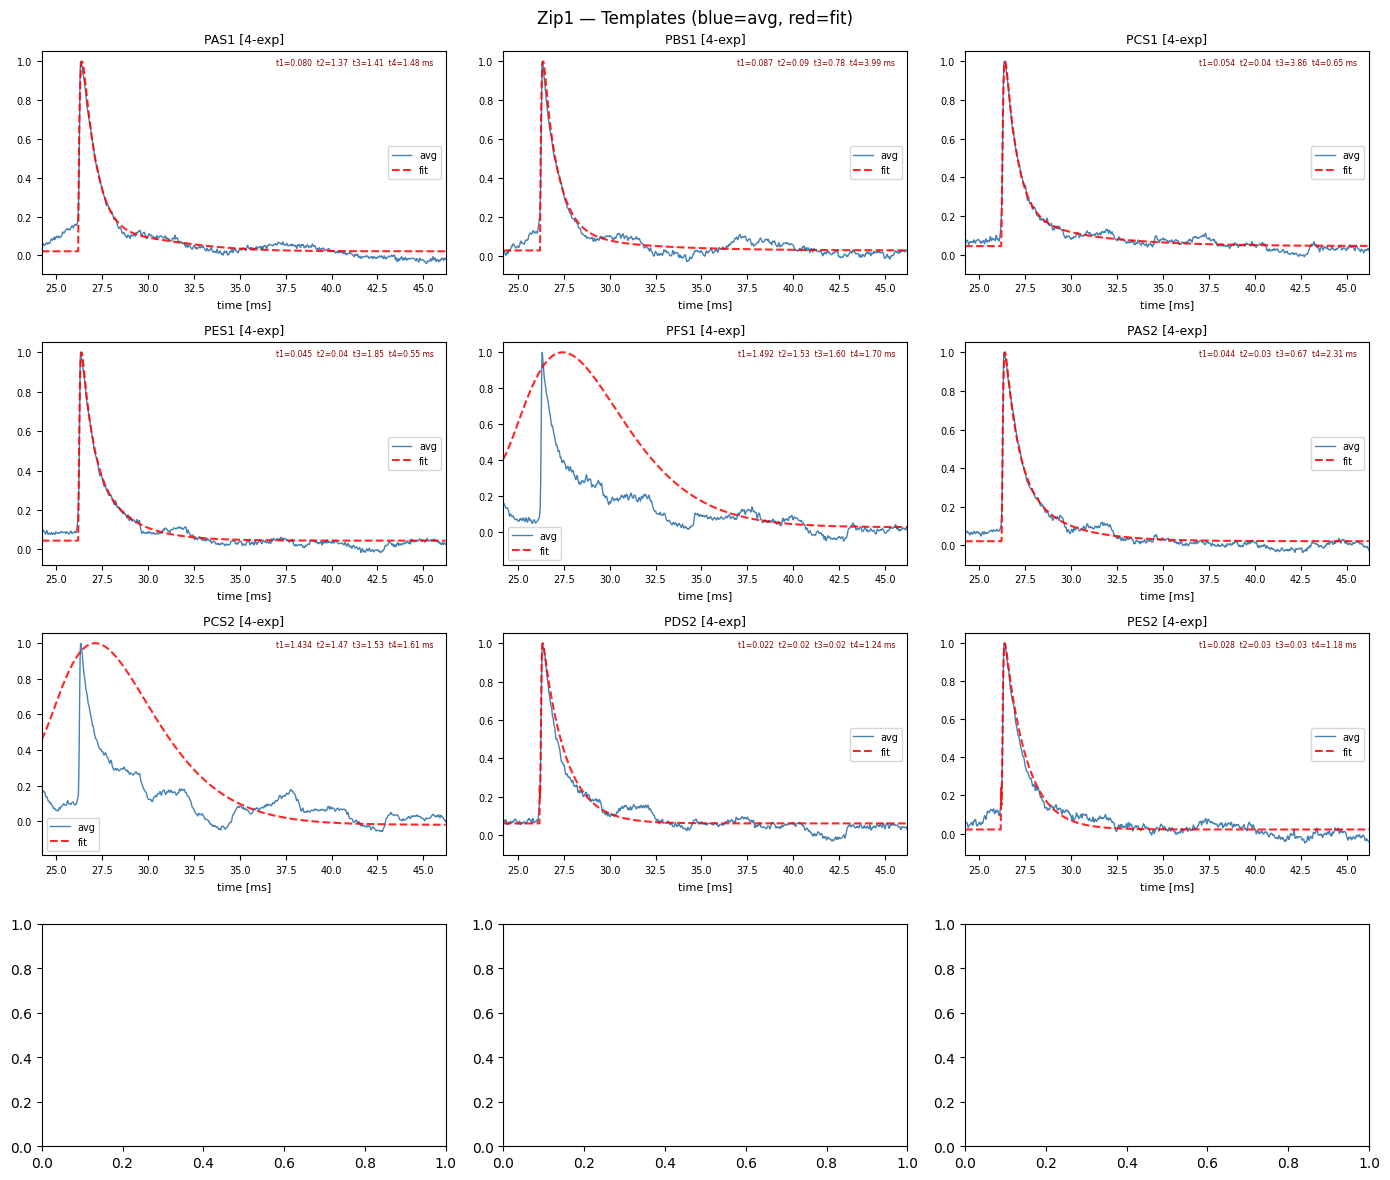

In [14]:
# Plot average templates (blue) with exponential fits (red dashed)
center_ms = (tracelength // 2) / samplerate * 1000

fig, axes = plt.subplots(4, 3, figsize=(14, 12), sharex=False)
axes = axes.flatten()

for idx, chan in enumerate(chan_names):
    ax   = axes[idx]
    tmpl = average_trace.get(chan)
    ft   = fit_avg_trace.get(chan)
    pd   = _plot_data.get(chan)

    if tmpl is not None:
        t_ms = np.arange(len(tmpl)) / samplerate * 1000
        ax.plot(t_ms, tmpl, color='steelblue', lw=1, label='avg')
    if ft is not None and pd is not None:
        t_ms = np.arange(len(ft)) / samplerate * 1000
        ax.plot(t_ms, ft, color='red', lw=1.5, ls='--', alpha=0.85, label='fit')
        ax.text(0.97, 0.97, pd[2], ha='right', va='top',
                transform=ax.transAxes, fontsize=5.5, color='darkred')
        ax.set_title(f"{chan} [{pd[0]}]", fontsize=9)
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(chan, fontsize=9)

    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
    ax.set_xlim(center_ms - 2, center_ms + 20)
    ax.set_xlabel('time [ms]', fontsize=8)

fig.suptitle(f"Zip{det_tmpl} — Templates (blue=avg, red=fit)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Summary table: fitted time constants and amplitudes
hdr = (f"{'Channel':8s}  {'Model':6s}  "
       f"{'amp1':>8s}  {'amp2':>8s}  {'amp3':>8s}  "
       f"{'t1 [ms]':>10s}  {'t2 [ms]':>10s}  {'t3 [ms]':>10s}  {'t4 [ms]':>10s}")
print(hdr)
print('-' * len(hdr))
for chan in chan_names:
    entry = fit_params.get(chan)
    if entry is None:
        print(f"  {chan:<6s}:  N/A")
    elif entry[0] == '4-exp':
        a1, a2, a3, t1, t2, t3, t4, bl, pt = entry[1]
        print(f"  {chan:<6s}:  4-exp  "
              f"{a1:>8.3f}  {a2:>8.3f}  {a3:>8.3f}  "
              f"{t1*1e3:>10.3f}  {t2*1e3:>10.2f}  {t3*1e3:>10.2f}  {t4*1e3:>10.2f}")
    elif entry[0] == '3-exp':
        a1, a2, t1, t2, t3, bl, pt = entry[1]
        print(f"  {chan:<6s}:  3-exp  "
              f"{a1:>8.3f}  {a2:>8.3f}  {'N/A':>8s}  "
              f"{t1*1e3:>10.3f}  {t2*1e3:>10.2f}  {t3*1e3:>10.2f}  {'N/A':>10s}")
    else:
        a1, t1, t2, bl, pt = entry[1]
        print(f"  {chan:<6s}:  2-exp  "
              f"{a1:>8.3f}  {'N/A':>8s}  {'N/A':>8s}  "
              f"{t1*1e3:>10.3f}  {t2*1e3:>10.2f}  {'N/A':>10s}  {'N/A':>10s}")

### Step 5 — Build PT / PS1 / PS2 and Write 1×1 Templates to ROOT

In [ ]:
# ── Three normalization types → three composite templates ─────────────────────
#
#  Type 1 — individual channels (already in fit_avg_trace[chan])
#
#  Type 2 — PS1 / PS2 (per-face sum):
#    Sum the fitted individual-channel templates within each face, then normalise.
#
#  Type 3 — PT (Phonon Full / PF method):
#    For each event the aligned channels were summed BEFORE normalisation (pf_traces).
#    Average those per-event sums → normalise → fit → normalise again.
#    This preserves the true relative weight of each channel.
#
ALL_12 = ['PAS1', 'PBS1', 'PCS1', 'PDS1', 'PES1', 'PFS1',
          'PAS2', 'PBS2', 'PCS2', 'PDS2', 'PES2', 'PFS2']

# ── Type 2: PS1 and PS2 ───────────────────────────────────────────────────────
trace_s1 = np.zeros(tracelength)
for c in ALL_12[:6]:
    if fit_avg_trace.get(c) is not None:
        trace_s1 += fit_avg_trace[c]
if np.max(trace_s1) > 0:
    fit_avg_trace['PS1'] = trace_s1 / np.max(trace_s1)

trace_s2 = np.zeros(tracelength)
for c in ALL_12[6:]:
    if fit_avg_trace.get(c) is not None:
        trace_s2 += fit_avg_trace[c]
if np.max(trace_s2) > 0:
    fit_avg_trace['PS2'] = trace_s2 / np.max(trace_s2)

# ── Type 3: PT via PF method ──────────────────────────────────────────────────
if pf_traces:
    pf_avg = np.mean(pf_traces, axis=0)
    pf_avg = pf_avg / np.max(pf_avg)
    average_trace['PT'] = pf_avg          # raw per-event average for display

    pt_g, t1_g, t2_g, t3_g, t4_g = auto_guess(pf_avg, WIN_START)
    t1_p0 = min(t1_g, T1_MAX * 0.99)
    x_pf  = np.arange(WIN_START, len(pf_avg), dtype=float)
    y_pf  = pf_avg[WIN_START:]
    x_full = np.arange(tracelength, dtype=float)

    pt_fitted = False
    for mode in ['4-exp', '3-exp', '2-exp']:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                if mode == '4-exp':
                    popt_pt, _ = curve_fit(
                        four_exp_fit, x_pf, y_pf,
                        p0=[0.4, 0.3, 0.3, t1_p0, t2_g, t3_g, t4_g, 0.0, pt_g],
                        bounds=([0, 0, 0, 0, 0, 0, 0, -np.inf, -np.inf],
                                [np.inf, np.inf, np.inf, T1_MAX,
                                 np.inf, np.inf, np.inf, np.inf, np.inf]),
                        maxfev=int(1e5))
                    pt_full = four_exp_fit(x_full, *popt_pt)
                    a1, a2, a3, t1, t2, t3, t4, bl, ptrg = popt_pt
                    pt_label = (f't1={t1*1e3:.3f}  t2={t2*1e3:.2f}  '
                                f't3={t3*1e3:.2f}  t4={t4*1e3:.2f} ms')
                elif mode == '3-exp':
                    popt_pt, _ = curve_fit(
                        three_exp_fit, x_pf, y_pf,
                        p0=[0.5, 0.5, t1_p0, t2_g, t3_g, 0.0, pt_g],
                        bounds=([0, 0, 0, 0, 0, -np.inf, -np.inf],
                                [np.inf, np.inf, T1_MAX, np.inf, np.inf,
                                 np.inf, np.inf]),
                        maxfev=int(1e5))
                    pt_full = three_exp_fit(x_full, *popt_pt)
                    a1, a2, t1, t2, t3, bl, ptrg = popt_pt
                    pt_label = (f't1={t1*1e3:.3f}  t2={t2*1e3:.2f}  '
                                f't3={t3*1e3:.2f} ms')
                else:
                    popt_pt, _ = curve_fit(
                        two_exp_fit, x_pf, y_pf,
                        p0=[1.0, t1_p0, t2_g, 0.0, pt_g],
                        bounds=([0, 0, 0, -np.inf, -np.inf],
                                [np.inf, T1_MAX, np.inf, np.inf, np.inf]),
                        maxfev=int(1e5))
                    pt_full = two_exp_fit(x_full, *popt_pt)
                    a1, t1, t2, bl, ptrg = popt_pt
                    pt_label = f't1={t1*1e3:.3f}  t2={t2*1e3:.2f} ms'

            peak_pt = np.max(pt_full)
            fit_avg_trace['PT'] = pt_full / peak_pt if peak_pt > 0 else pt_full
            print(f"PT [PF method, {len(pf_traces)} events, {mode}]: {pt_label}")
            pt_fitted = True
            break
        except RuntimeError:
            if mode != '2-exp':
                print(f"PT: {mode} failed, trying next")
            else:
                print("PT: all fits failed — storing raw PF average")
                fit_avg_trace['PT'] = pf_avg
else:
    print("WARNING: no PF traces — falling back to sum of individual fitted channels")
    trace_pt = np.zeros(tracelength)
    for c in ALL_12:
        if fit_avg_trace.get(c) is not None:
            trace_pt += fit_avg_trace[c]
    if np.max(trace_pt) > 0:
        fit_avg_trace['PT'] = trace_pt / np.max(trace_pt)

# ── Plot PT / PS1 / PS2 ───────────────────────────────────────────────────────
center_ms = (tracelength // 2) / samplerate * 1000
t_ms      = np.arange(tracelength) / samplerate * 1000

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, label in zip(axes, ['PT', 'PS1', 'PS2']):
    raw_tr = average_trace.get(label)
    fit_tr = fit_avg_trace.get(label)
    if raw_tr is not None:
        ax.plot(t_ms, raw_tr, color='steelblue', lw=1, label='avg')
    if fit_tr is not None:
        ax.plot(t_ms, fit_tr, color='red', lw=1.5, ls='--', alpha=0.85, label='fit')
    ax.set_xlim(center_ms - 2, center_ms + 20)
    ax.set_title(f"{label} composite template", fontsize=11)
    ax.set_xlabel('time [ms]')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
# Write 1×1 templates to ROOT — format follows Ge-TemplateGeneration.ipynb
output_1x1 = f"Templates_SNOLAB_R4_zip{det_tmpl}_1x1.root"
root_file  = TFile(output_1x1, "RECREATE")
directory  = root_file.mkdir(f"zip{det_tmpl}").cd()

write_chans = ['PAS1', 'PBS1', 'PCS1', 'PDS1', 'PES1', 'PFS1',
               'PAS2', 'PBS2', 'PCS2', 'PDS2', 'PES2', 'PFS2',
               'PT', 'PS1', 'PS2']
n_bins = tracelength

for channel in write_chans:
    tr = fit_avg_trace.get(channel)
    if tr is None:
        print(f"  {channel}: skipped (no template)")
        continue
    tr_norm = tr / np.max(tr)
    h = TH1D(channel, channel, n_bins, 0, n_bins)
    for i, v in enumerate(tr_norm):
        h.SetBinContent(i + 1, v)
    h.Write()
    print(f"  {channel}: written")

root_file.Close()
print(f"\nSaved: {os.path.abspath(output_1x1)}")

  PAS1: written
  PBS1: written
  PCS1: written
  PDS1: skipped (no template)
  PES1: written
  PFS1: written
  PAS2: written
  PBS2: skipped (no template)
  PCS2: written
  PDS2: written
  PES2: written
  PFS2: skipped (no template)
  PT: written
  PS1: written
  PS2: written

Saved: /users/9/li004628/urop/snolab/Templates_SNOLAB_R4_zip1_1x1.root


---
## Part 3 — N×M Template Generation (PCA)

**Pipeline:**  
1. Re-use aligned traces; cut to a 6000-sample window around the pulse  
2. PCA to extract principal components (N_COMPONENTS per channel)  
3. Optional: remove spurious sine artefact from a component  
4. Pad components back to full trace length and write to ROOT  

In [18]:
# NxM training: fit each event with four_exp_fit, generate normalised synthetic trace
# This follows NxM_cedar.ipynb: fit first → normalise → PCA on fitted traces
WIN_NXM_LO   = 14000
WIN_NXM_HI   = 20000
WIN_NXM      = WIN_NXM_HI - WIN_NXM_LO    # 6000 samples
N_COMPONENTS = 4
MAX_EVENTS   = 200
x_win        = np.arange(WIN_NXM, dtype=float)

# canonical pretrigger in the cut window (peak near 16384, window starts at 14000)
SYNTH_PT = float(16384 - WIN_NXM_LO - 200)   # ≈ 2184 within window

def chan_p0_nxm(chan):
    """Initial guess for four_exp_fit from average trace fit parameters."""
    entry = fit_params.get(chan)
    if entry is None:
        return None
    tag, popt = entry
    if tag == '4-exp':
        a1, a2, a3, t1, t2, t3, t4, bl, pt = popt
        return [a1, a2, a3, t1, t2, t3, t4, 0.0, SYNTH_PT]
    elif tag == '3-exp':
        a1, a2, t1, t2, t3, bl, pt = popt
        return [a1/2, a2/2, a2/2, t1, t2, t3, t3 * 3, 0.0, SYNTH_PT]
    else:
        a1, t1, t2, bl, pt = popt
        return [a1/3, a1/3, a1/3, t1, t2, t2 * 5, t2 * 20, 0.0, SYNTH_PT]

training_set = {c: [] for c in chan_names}

for chan in chan_names:
    traces = channel_traces[chan]
    if not traces:
        print(f"  {chan}: no traces")
        continue
    p0 = chan_p0_nxm(chan)
    if p0 is None:
        print(f"  {chan}: no avg fit params")
        continue

    n_fit = 0
    n_raw = 0
    for tr in traces[:MAX_EVENTS]:
        cut = tr[WIN_NXM_LO:WIN_NXM_HI]
        if len(cut) < WIN_NXM:
            continue
        peak_pos = int(np.argmax(cut))
        if peak_pos < 1500 or peak_pos > 3500:
            continue  # misaligned

        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                popt_ev, _ = curve_fit(
                    four_exp_fit, x_win, cut,
                    p0=p0, maxfev=int(3e4)
                )
            a1, a2, a3, t1, t2, t3, t4, bl, pt_ev = popt_ev
            # Generate clean synthetic trace with canonical amp/bl/pt
            synth = four_exp_fit(x_win, a1, a2, a3, t1, t2, t3, t4, 0.0, SYNTH_PT)
            peak_s = np.max(synth)
            if peak_s <= 0:
                continue
            training_set[chan].append(synth / peak_s)
            n_fit += 1
        except RuntimeError:
            # Fallback: use the filtered aligned cut trace directly
            training_set[chan].append(cut)
            n_raw += 1

    print(f"  {chan}: {n_fit} fitted + {n_raw} raw fallback = {n_fit+n_raw} training events")

/tmp/ipykernel_2113350/1766607968.py:21: RuntimeWarning: overflow encountered in exp
  -((amp1 + amp2 + amp3) * np.exp(-(x - pretrigger) / t1 / samplerate)


  PAS1: 93 fitted + 9 raw fallback = 102 training events


/tmp/ipykernel_2113350/1766607968.py:24: RuntimeWarning: overflow encountered in exp
  - amp3                * np.exp(-(x - pretrigger) / t4 / samplerate)) + baseline


  PBS1: 43 fitted + 55 raw fallback = 98 training events


/tmp/ipykernel_2113350/1766607968.py:22: RuntimeWarning: overflow encountered in exp
  - amp1                * np.exp(-(x - pretrigger) / t2 / samplerate)


  PCS1: 49 fitted + 48 raw fallback = 97 training events


/tmp/ipykernel_2113350/1766607968.py:22: RuntimeWarning: overflow encountered in exp
  - amp1                * np.exp(-(x - pretrigger) / t2 / samplerate)
/tmp/ipykernel_2113350/1766607968.py:22: RuntimeWarning: overflow encountered in exp
  - amp1                * np.exp(-(x - pretrigger) / t2 / samplerate)


  PES1: 50 fitted + 41 raw fallback = 91 training events
  PFS1: 57 fitted + 20 raw fallback = 77 training events


/tmp/ipykernel_2113350/1766607968.py:22: RuntimeWarning: overflow encountered in exp
  - amp1                * np.exp(-(x - pretrigger) / t2 / samplerate)


  PAS2: 62 fitted + 33 raw fallback = 95 training events
  PCS2: 50 fitted + 19 raw fallback = 69 training events
  PDS2: 69 fitted + 22 raw fallback = 91 training events
  PES2: 78 fitted + 17 raw fallback = 95 training events


In [ ]:
# Plot NxM training set overlay + average for a few channels
avail_chans = [c for c in chan_names if training_set.get(c)]
if not avail_chans:
    print("No training events — check four_exp_fit convergence")
else:
    n_show = min(4, len(avail_chans))
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    for ax, chan in zip(axes, avail_chans[:n_show]):
        for tr in training_set[chan][:50]:
            ax.plot(tr, alpha=0.2, color='black', linewidth=0.4)
        avg_tr = np.mean(training_set[chan], axis=0)
        ax.plot(avg_tr, color='steelblue', linewidth=1.5,
                label=f'avg N={len(training_set[chan])}')
        ax.legend(fontsize=7)
        ax.set_title(chan)
        ax.ticklabel_format(style='sci', scilimits=(0,0))
    plt.suptitle('NxM training — fitted synthetic traces (6000 samples)', fontsize=11)
    plt.tight_layout()
    plt.show()

In [ ]:
# PCA on combined training set (all channels concatenated)
combined = []
for chan in chan_names:
    if training_set.get(chan):
        combined.extend(training_set[chan])

if len(combined) == 0:
    raise RuntimeError("No training events for PCA — check four_exp_fit convergence")

pca = PCA(N_COMPONENTS, svd_solver='full').fit(combined)
PC  = pca.components_   # shape (N_COMPONENTS, 6000)
var = pca.explained_variance_ratio_

print(f"PCA on {len(combined)} synthetic traces ({N_COMPONENTS} components)")
for i, v in enumerate(var):
    print(f"  PC{i}: {v*100:.2f}% variance")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(N_COMPONENTS), var, 'o-', color='steelblue')
ax.set_xlabel('Component index')
ax.set_ylabel('Explained variance ratio')
ax.set_title(f'Zip{det_tmpl} PCA explained variance')
ax.set_yscale('log')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Plot PCA components
n_cols = min(N_COMPONENTS, 4)
n_rows = (N_COMPONENTS + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).flatten()
x_cut = np.arange(WIN_NXM)
for i in range(N_COMPONENTS):
    ax = axes[i]
    ax.plot(x_cut, PC[i], linewidth=0.8)
    ax.set_title(f'PC{i}  ({var[i]*100:.2f}%)', fontsize=10)
    ax.ticklabel_format(style='sci', scilimits=(0,0))
for i in range(N_COMPONENTS, len(axes)):
    axes[i].set_visible(False)
fig.suptitle(f'Zip{det_tmpl} — PCA components (N×M templates)', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# Optional sine-wave cleaning for a specific component — only if visible artefact
# Uncomment and tune if a component shows a clear periodic artefact

# def sine_func(x, A, B, C, D):
#     return A * np.sin(B * x + C) + D
#
# comp_to_clean = 3   # inspect plots above and set which component has the sine
# x_fit = np.linspace(0, len(PC[comp_to_clean]), len(PC[comp_to_clean]))
# popt_sine, _ = curve_fit(sine_func, x_fit, PC[comp_to_clean],
#                           p0=[0.02, 1e-3, 0, 0.01], maxfev=50000)
# PC[comp_to_clean] = PC[comp_to_clean] - sine_func(x_fit, *popt_sine)
# print(f"Sine removed from PC{comp_to_clean}")

print("Sine cleaning skipped — uncomment above block if needed.")

Sine cleaning skipped — uncomment above block if needed.


In [ ]:
# Write NxM templates to ROOT — pad component back to full 32768 trace length
# Pad: WIN_NXM_LO zeros before, 6000 component samples, remaining zeros after
output_nxm = f"Templates_SNOLAB_R4_zip{det_tmpl}_1x1.root"
rootfile   = ROOT.TFile.Open(output_nxm, 'UPDATE')
rootfile.cd(f"zip{det_tmpl}")

n_bins = tracelength
n_post = n_bins - WIN_NXM_HI   # 32768 - 20000 = 12768

for chan in chan_names:
    for i in range(N_COMPONENTS):
        hname = f"{chan}nxm{i}"
        h = ROOT.TH1D(hname, hname, n_bins, 0, n_bins)
        padded = np.pad(PC[i], pad_width=(WIN_NXM_LO, 0), mode='constant')
        padded = np.pad(padded, pad_width=(0, n_post),     mode='constant')
        padded = padded[:n_bins]
        peak_p = np.max(np.abs(padded))
        y = padded / peak_p if peak_p > 0 else padded
        for j, v in enumerate(y):
            h.SetBinContent(j + 1, v)
        h.Write()
        h.Delete()

rootfile.Close()
print(f"NxM templates ({N_COMPONENTS} components × {len(chan_names)} channels) written.")
print(f"Saved: {os.path.abspath(output_nxm)}")

### Verify Output

In [ ]:
# Read back and verify written templates
r = ROOT.TFile.Open(output_nxm)
r.ls()

avail_1x1 = [c for c in ['PAS1','PBS1','PCS1','PES1','PFS1',
                           'PAS2','PCS2','PDS2','PES2','PT','PS1','PS2']
             if r.Get(f"zip{det_tmpl}/{c}")]
print(f"1×1 templates present: {avail_1x1}")

if avail_1x1:
    n_show = min(4, len(avail_1x1))
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    for ax, chan in zip(axes, avail_1x1[:n_show]):
        h = r.Get(f"zip{det_tmpl}/{chan}")
        y = np.array([h.GetBinContent(b+1) for b in range(h.GetNbinsX())])
        ax.plot(y, lw=0.8, color='steelblue')
        ax.set_xlim(tracelength//2 - 2000, tracelength//2 + 4000)
        ax.set_title(f"{chan} 1×1", fontsize=9)
    plt.suptitle('1×1 templates from ROOT', fontsize=11)
    plt.tight_layout()
    plt.show()

avail_nxm = [c for c in chan_names if r.Get(f"zip{det_tmpl}/{c}nxm0")]
print(f"NxM channels present: {avail_nxm}")

r.Close()